# 35 — Transformer Sequence Classifier

We now use the reusable positional, attention, and Transformer components to train a small sequence classifier. The synthetic task is intentionally simple: determine whether a variable-length sequence contains a designated signal token. This keeps the experiment fast while exposing the complete path from token IDs to a sequence-level prediction.

## Learning objectives

- prepare padded token sequences and attention masks;
- use a classification token to summarize a sequence;
- assemble embedding, positional encoding, encoder, and classifier layers;
- route gradients through the complete model;
- train and evaluate a small Transformer classifier;
- inspect what the classification token attends to.


In [33]:
import matplotlib.pyplot as plt
import numpy as np

from cs231n_practice.layers import softmax_loss
from cs231n_practice.positional_encoding import add_positional_encoding
from cs231n_practice.sequence_layers import embedding_backward, embedding_forward
from cs231n_practice.transformer import (
    transformer_encoder_block_backward,
    transformer_encoder_block_forward,
)

SEED = 42
generator = np.random.default_rng(SEED)
np.set_printoptions(precision=3, suppress=True)

PAD_ID = 0
CLS_ID = 1
SIGNAL_ID = 2
VOCABULARY_SIZE = 12
SEQUENCE_LENGTH = 8


## 1. Synthetic variable-length sequences

Position 0 is always `[CLS]`. Real data tokens follow it, and unused positions contain `[PAD]`. Half of the examples contain `[SIGNAL]` at one random valid position and have label 1; the others contain only ordinary tokens and have label 0.

`valid_tokens[n, t]` is `True` for `[CLS]` and real tokens and `False` for padding. The label depends on the complete sequence, so the classifier needs one sequence-level representation.

### Exercise 1 — Generate and inspect the data


In [34]:
def make_signal_dataset(num_examples, generator):
    token_ids = np.full(
        (num_examples, SEQUENCE_LENGTH), PAD_ID, dtype=np.int64
    )
    valid_tokens = np.zeros_like(token_ids, dtype=bool)
    labels = generator.integers(0, 2, size=num_examples)

    token_ids[:, 0] = CLS_ID
    valid_tokens[:, 0] = True
    for example_index, label in enumerate(labels):
        data_length = generator.integers(2, SEQUENCE_LENGTH)
        token_ids[example_index, 1 : data_length + 1] = generator.integers(
            3, VOCABULARY_SIZE, size=data_length
        )
        valid_tokens[example_index, : data_length + 1] = True
        if label == 1:
            signal_position = generator.integers(1, data_length + 1)
            token_ids[example_index, signal_position] = SIGNAL_ID
    return token_ids, valid_tokens, labels


train_ids, train_valid, train_labels = make_signal_dataset(600, generator)
validation_ids, validation_valid, validation_labels = make_signal_dataset(200, generator)

# verify that padding positions contain PAD_ID and that every
# positive example contains SIGNAL_ID in at least one valid position.
# Invalid positions must contain PAD.
assert np.all(train_ids[~train_valid] == PAD_ID)

# Valid positions must not contain PAD.
assert np.all(train_ids[train_valid] != PAD_ID)

# Position 0 must always contain CLS and be valid.
assert np.all(train_ids[:, 0] == CLS_ID)
assert np.all(train_valid[:, 0])

# An example contains SIGNAL exactly when its label is 1.
contains_signal = np.any(
    (train_ids == SIGNAL_ID) & train_valid,
    axis=1,
)
np.testing.assert_array_equal(
    contains_signal,
    train_labels.astype(bool),
)

for index in range(5):
    print(
        f"label={train_labels[index]}  ",
        f"valid={train_valid[index].sum()}  ",
        train_ids[index],
    )


label=0   valid=6   [ 1 10  9  4 10  7  0  0]
label=1   valid=4   [ 1  7 11  2  0  0  0  0]
label=1   valid=5   [1 2 6 9 8 0 0 0]
label=0   valid=4   [1 3 4 6 0 0 0 0]
label=0   valid=5   [1 4 6 8 5 0 0 0]


## 2. Classification-token pooling and the padding mask

The learned `[CLS]` embedding begins at position 0. Self-attention allows its representation to retrieve information from every valid token. After the encoder block, we use only the contextualized vector at position 0 for classification:

```text
encoded sequence:  (N, L, D)
CLS representation: encoded[:, 0, :] -> (N, D)
class scores:       (N, D) @ (D, C) -> (N, C)
```

The validity array $(N,L)$ becomes an attention mask $(N,1,1,L)$. Its singleton head and query axes broadcast the same valid-key restriction to every head and query. `[CLS]` is always valid, so every query has at least one allowed key.

### Exercise 2 — Construct and verify the mask


In [35]:
def make_padding_mask(valid_tokens):
    """Convert (N, L) token validity to an attention key mask."""
    # insert singleton head and query dimensions.
    return valid_tokens[:, None, None, :]
    # return valid_tokens[:, np.newaxis, np.newaxis, :].astype(np.bool_)


example_mask = make_padding_mask(train_valid[:4])
assert example_mask.shape == (4, 1, 1, SEQUENCE_LENGTH)
assert example_mask.dtype == np.bool_
np.testing.assert_array_equal(example_mask[:, 0, 0], train_valid[:4])


## 3. Initialize and assemble the classifier

The model follows this path:

```text
token IDs -> learned embeddings -> add fixed positional encoding
          -> pre-norm Transformer encoder block
          -> select encoded [CLS] -> affine class scores
```

The positional encoding is fixed, so it has no trainable gradient. The token embedding, all encoder parameters, and final classifier are learned.

### Exercise 3 — Implement the forward pass


In [36]:
MODEL_DIM = 12
FEED_FORWARD_DIM = 24
NUM_HEADS = 3
NUM_CLASSES = 2

def initialize_parameters(generator):
    scale = 0.08
    return {
        "embedding": generator.normal(scale=scale, size=(VOCABULARY_SIZE, MODEL_DIM)),
        "gamma1": np.ones(MODEL_DIM),
        "beta1": np.zeros(MODEL_DIM),
        "W_query": generator.normal(scale=scale, size=(MODEL_DIM, MODEL_DIM)),
        "W_key": generator.normal(scale=scale, size=(MODEL_DIM, MODEL_DIM)),
        "W_value": generator.normal(scale=scale, size=(MODEL_DIM, MODEL_DIM)),
        "W_output": generator.normal(scale=scale, size=(MODEL_DIM, MODEL_DIM)),
        "b_query": np.zeros(MODEL_DIM),
        "b_key": np.zeros(MODEL_DIM),
        "b_value": np.zeros(MODEL_DIM),
        "b_output": np.zeros(MODEL_DIM),
        "gamma2": np.ones(MODEL_DIM),
        "beta2": np.zeros(MODEL_DIM),
        "W1": generator.normal(scale=scale, size=(MODEL_DIM, FEED_FORWARD_DIM)),
        "b1": np.zeros(FEED_FORWARD_DIM),
        "W2": generator.normal(scale=scale, size=(FEED_FORWARD_DIM, MODEL_DIM)),
        "b2": np.zeros(MODEL_DIM),
        "W_classifier": generator.normal(scale=scale, size=(MODEL_DIM, NUM_CLASSES)),
        "b_classifier": np.zeros(NUM_CLASSES),
    }


def classifier_forward(token_ids, valid_tokens, parameters):
    """Return class scores, attention weights, and backward cache."""
    # look up token embeddings and add sinusoidal positions.
    embeddings, embedding_cache = embedding_forward(
        token_ids, parameters["embedding"]
    )
    positional_embeddings = add_positional_encoding(embeddings)
    # run the encoder with a padding mask.
    attention_mask = make_padding_mask(valid_tokens)
    encoder_output, attention_weights, encoder_cache = transformer_encoder_block_forward(
        positional_embeddings,
        parameters,
        num_heads=NUM_HEADS,
        mask=attention_mask,
    )

    # select position 0 and calculate class scores.
    cls_representation = encoder_output[:, 0, :]
    scores = cls_representation @ parameters["W_classifier"] + parameters["b_classifier"]

    # Cache what backward needs: embedding cache, encoder cache, and
    # the encoded CLS representations.
    cache = {
        "embedding_cache": embedding_cache,
        "encoder_cache": encoder_cache,
        "encoder_output": encoder_output,
        "cls_representation": cls_representation,
    }
    return scores, attention_weights, cache


parameters = initialize_parameters(generator)
scores, initial_attention, classifier_cache = classifier_forward(
    train_ids[:5], train_valid[:5], parameters
)
assert scores.shape == (5, NUM_CLASSES)
assert initial_attention.shape == (5, NUM_HEADS, SEQUENCE_LENGTH, SEQUENCE_LENGTH)


## 4. Loss and backward pass

Softmax cross-entropy supplies the class-score gradient. Only the encoded `[CLS]` position feeds the classifier, so the initial encoder-output gradient is zero at every other position. Attention then propagates the `[CLS]` loss signal into embeddings at other valid positions.

The fixed positional addition has derivative 1 with respect to the token embeddings. Therefore, the gradient returned for the encoder input can pass directly into `embedding_backward`.

### Exercise 4 — Implement the complete loss


In [37]:
def classifier_loss(token_ids, valid_tokens, labels, parameters):
    """Return mean classification loss and every parameter gradient."""
    # run classifier_forward and softmax_loss.
    scores, attention_weights, cache = classifier_forward(token_ids, valid_tokens, parameters)
    loss, d_scores = softmax_loss(scores, labels)

    # backpropagate through the classifier using only CLS position 0.
    d_cls_representation = d_scores @ parameters["W_classifier"].T
    d_W_classifier = cache["cls_representation"].T @ d_scores
    d_b_classifier = np.sum(d_scores, axis=0)

    # backpropagate through the encoder and embedding lookup.
    d_encoder_output = np.zeros_like(cache["encoder_output"])
    d_encoder_output[:, 0, :] = d_cls_representation
    d_positional_embeddings, d_parameters = transformer_encoder_block_backward(
        d_encoder_output, cache["encoder_cache"]
    )
    d_embedding = embedding_backward(d_positional_embeddings, cache["embedding_cache"])
    # Return the loss and one gradient dictionary keyed like parameters.
    return loss, {
        "embedding": d_embedding,
        "gamma1": d_parameters["gamma1"],
        "beta1": d_parameters["beta1"],
        "W_query": d_parameters["W_query"],
        "W_key": d_parameters["W_key"],
        "W_value": d_parameters["W_value"],
        "W_output": d_parameters["W_output"],
        "b_query": d_parameters["b_query"],
        "b_key": d_parameters["b_key"],
        "b_value": d_parameters["b_value"],
        "b_output": d_parameters["b_output"],
        "gamma2": d_parameters["gamma2"],
        "beta2": d_parameters["beta2"],
        "W1": d_parameters["W1"],
        "b1": d_parameters["b1"],
        "W2": d_parameters["W2"],
        "b2": d_parameters["b2"],
        "W_classifier": d_W_classifier,
        "b_classifier": d_b_classifier,
    }


initial_loss, initial_gradients = classifier_loss(
    train_ids[:8], train_valid[:8], train_labels[:8], parameters
)
assert np.isfinite(initial_loss)
assert initial_gradients.keys() == parameters.keys()
for name in parameters:
    assert initial_gradients[name].shape == parameters[name].shape
print(f"Initial minibatch loss: {initial_loss:.4f}")


Initial minibatch loss: 0.6966


## 5. Train and evaluate

We use minibatch SGD so the experiment remains transparent. Record both training loss and validation accuracy periodically. The task is deliberately easy enough for a one-block model to learn quickly.

### Exercise 5 — Run the optimization loop


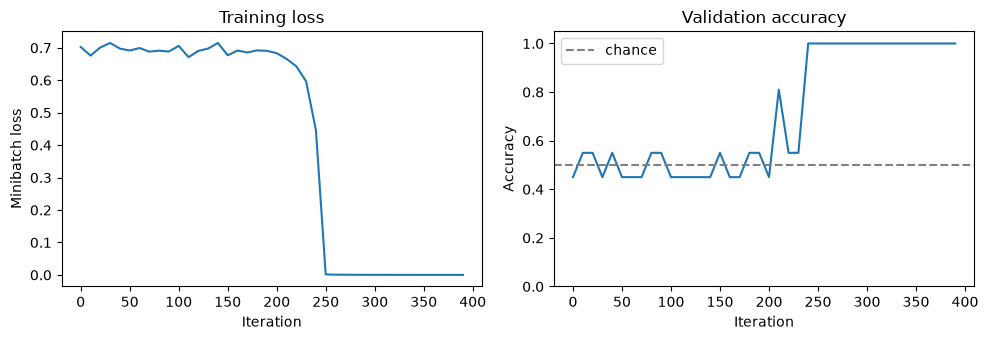

Final training accuracy:   1.000
Final validation accuracy: 1.000


In [ ]:
def accuracy(token_ids, valid_tokens, labels, parameters):
    scores, _, _ = classifier_forward(token_ids, valid_tokens, parameters)
    return np.mean(np.argmax(scores, axis=1) == labels)


learning_rate = 0.5
batch_size = 64
num_iterations = 400
loss_history = []
iteration_history = []
validation_accuracy_history = []

# on each iteration, sample row indices without replacement, compute
# loss/gradients, and update every parameter with SGD. Every 10 iterations,
# record the loss and validation accuracy.
for iteration in range(num_iterations):
    batch_indices = generator.choice(
        train_ids.shape[0], size=batch_size, replace=False
    )
    batch_ids = train_ids[batch_indices]
    batch_valid = train_valid[batch_indices]
    batch_labels = train_labels[batch_indices]

    loss, gradients = classifier_loss(batch_ids, batch_valid, batch_labels, parameters)
    for name in parameters:
        parameters[name] -= learning_rate * gradients[name]

    if iteration % 10 == 0:
        iteration_history.append(iteration)
        loss_history.append(loss)
        validation_accuracy_history.append(
            accuracy(validation_ids, validation_valid, validation_labels, parameters)
        )

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].plot(iteration_history, loss_history)
axes[0].set_xlabel("Iteration")
axes[0].set_ylabel("Minibatch loss")
axes[0].set_title("Training loss")
axes[1].plot(iteration_history, validation_accuracy_history)
axes[1].axhline(0.5, color="gray", linestyle="--", label="chance")
axes[1].set_xlabel("Iteration")
axes[1].set_ylabel("Accuracy")
axes[1].set_ylim(0, 1.05)
axes[1].set_title("Validation accuracy")
axes[1].legend()
plt.tight_layout()
plt.show()

final_train_accuracy = accuracy(train_ids, train_valid, train_labels, parameters)
final_validation_accuracy = accuracy(
    validation_ids, validation_valid, validation_labels, parameters
)
print(f"Final training accuracy:   {final_train_accuracy:.3f}")
print(f"Final validation accuracy: {final_validation_accuracy:.3f}")
assert final_validation_accuracy > 0.9


## 6. Inspect `[CLS]` attention

For one positive validation example, inspect the weights produced by query position 0. Each head has its own distribution over valid key positions. A trained head may place strong weight on `[SIGNAL]`, but attention is not guaranteed to provide a complete explanation of the prediction.

### Exercise 6 — Visualize the heads


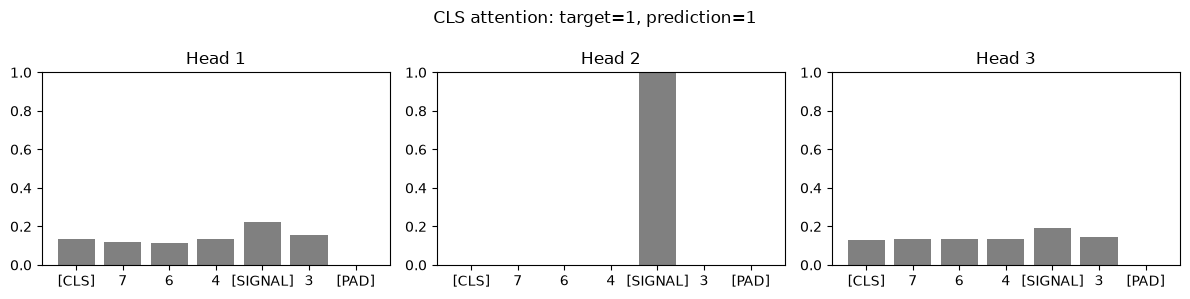

In [53]:
positive_index = np.flatnonzero(validation_labels == 1)[0]
sample_ids = validation_ids[positive_index : positive_index + 1]
sample_valid = validation_valid[positive_index : positive_index + 1]
sample_scores, sample_attention, _ = classifier_forward(
    sample_ids, sample_valid, parameters
)
predicted_label = int(np.argmax(sample_scores[0]))

token_names = [
    "[PAD]" if token == PAD_ID else
    "[CLS]" if token == CLS_ID else
    "[SIGNAL]" if token == SIGNAL_ID else str(token)
    for token in sample_ids[0]
]
fig, axes = plt.subplots(1, NUM_HEADS, figsize=(4 * NUM_HEADS, 3))
# for each head, draw a bar chart of sample_attention[0, head, 0].
# Use token_names as x labels and mark padded bars clearly.
for head in range(NUM_HEADS):
    axes[head].bar(
        token_names,
        sample_attention[0, head, 0],
        color=["gray" if valid else "lightgray" for valid in sample_valid[0]],
    )
    axes[head].set_ylim(0, 1)
    axes[head].set_title(f"Head {head+1}")
fig.suptitle(
    f"CLS attention: target=1, prediction={predicted_label}"
)
plt.tight_layout()
plt.show()


## Reflection

Answer briefly in your own words.

1. What is the purpose of the `[CLS]` token in this model?
2. Why is the padding mask shaped $(N,1,1,L)$?
3. Why is only encoder position 0 connected directly to the classifier?
4. How can tokens at other positions still receive classification gradients?
5. Why does this encoder use a padding mask but not a causal mask?
6. What would this successful synthetic experiment not prove about Transformers?

### Answers

1. gather all context for final prediction. [CLS] provides a dedicated position whose contextualized representation summarizes information needed for the sequence-level prediction.
2. The mask has shape $(N,1,1,L)$ so each example can have its own valid keys, while the singleton axes broadcast the same restriction across every attention head and query position.
3. Position 0 is connected to the classifier because [CLS] is intentionally used as the sequence summary. This avoids directly classifying every token position. it aggregate all required details from all other position throug attention
4. The [CLS] query attends to other token positions. During backward propagation, the gradient from [CLS] flows through the attention weights and values into those token representations and their embeddings.
5. in this type of prediction we should always check full sequence tokens. Classification can use the complete input sequence, so every valid token may attend to tokens on either side. A causal mask is necessary for autoregressive generation, where future tokens must remain hidden, but not for this encoder classification task.
6. Success on this simple synthetic detection task does not prove that the model understands language, generalizes to realistic problems, or that Transformers are always superior to simpler models. The dataset contains a direct and easily detectable signal.
